# Healthcare Routing Model Validation

## Challenge Goal
Build a **"living map of healthcare"** that helps patients find the optimal hospital by considering:
- 🏥 Hospital availability
- 📍 Distance/travel time
- ⏱️ Wait times
- 👥 Hospital capacity

## Validation Objectives
1. Verify model performance meets production standards
2. Confirm optimal hospital selection accuracy
3. Validate feature importance aligns with challenge goals
4. Generate frontend-ready visualizations
5. Provide deployment readiness assessment

In [0]:
import pandas as pd
import numpy as np
import pickle
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 1. Load Model & Results Files
Loading all trained models, scalers, and prediction results from the parent directory.

In [0]:
import os

# Define file paths - corrected to actual location
model_path = '../ML&AI/models/best_model.pkl'
scaler_path = '../ML&AI/models/scaler.pkl'
info_path = '../ML&AI/models/best_model_info.json'
predictions_path = '../ML&AI/results/test_predictions.csv'
metrics_path = '../ML&AI/results/all_models_metrics.csv'
cv_scores_path = '../ML&AI/results/cross_validation_scores.csv'

# Check file existence
files_to_check = {
    'Model': model_path,
    'Scaler': scaler_path,
    'Model Info': info_path,
    'Test Predictions': predictions_path,
    'Model Metrics': metrics_path,
    'CV Scores': cv_scores_path
}

print("\n📁 Checking files...\n")
missing_files = []
for name, path in files_to_check.items():
    if os.path.exists(path):
        print(f"✅ {name}: {path}")
    else:
        print(f"❌ {name}: {path} NOT FOUND")
        missing_files.append(name)

if missing_files:
    print(f"\n⚠️ Warning: {len(missing_files)} file(s) missing: {', '.join(missing_files)}")
else:
    print("\n✅ All files found!")


📁 Checking files...

✅ Model: ../ML/AI/models/best_model.pkl
✅ Scaler: ../ML/AI/models/scaler.pkl
✅ Model Info: ../ML/AI/models/best_model_info.json
✅ Test Predictions: ../ML/AI/results/test_predictions.csv
✅ Model Metrics: ../ML/AI/results/all_models_metrics.csv
✅ CV Scores: ../ML/AI/results/cross_validation_scores.csv

✅ All files found!


In [0]:
# Load the trained model
try:
    with open(model_path, 'rb') as f:
        best_model = pickle.load(f)
    print("✅ Model loaded successfully")
    print(f"   Model type: {type(best_model).__name__}")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    best_model = None

# Load the scaler
try:
    with open(scaler_path, 'rb') as f:
        scaler = pickle.load(f)
    print("✅ Scaler loaded successfully")
    print(f"   Scaler type: {type(scaler).__name__}")
except Exception as e:
    print(f"❌ Error loading scaler: {e}")
    scaler = None

# Load model info
try:
    with open(info_path, 'r') as f:
        model_info = json.load(f)
    print("✅ Model info loaded successfully")
except Exception as e:
    print(f"❌ Error loading model info: {e}")
    model_info = {}

# Load predictions
try:
    test_predictions = pd.read_csv(predictions_path)
    print(f"✅ Test predictions loaded: {len(test_predictions)} samples")
except Exception as e:
    print(f"❌ Error loading predictions: {e}")
    test_predictions = None

# Load all model metrics
try:
    all_metrics = pd.read_csv(metrics_path)
    print(f"✅ Model metrics loaded: {len(all_metrics)} models compared")
except Exception as e:
    print(f"❌ Error loading metrics: {e}")
    all_metrics = None

# Load CV scores
try:
    cv_scores = pd.read_csv(cv_scores_path)
    print(f"✅ CV scores loaded: {len(cv_scores)} models evaluated")
except Exception as e:
    print(f"❌ Error loading CV scores: {e}")
    cv_scores = None

✅ Model loaded successfully
   Model type: RandomForestClassifier
✅ Scaler loaded successfully
   Scaler type: StandardScaler
✅ Model info loaded successfully
✅ Test predictions loaded: 25463 samples
✅ Model metrics loaded: 4 models compared
✅ CV scores loaded: 4 models evaluated


## 2. Model Performance Summary
Evaluating the best model's performance on test data.

In [0]:
print("="*70)
print("MODEL INFORMATION")
print("="*70)

if model_info:
    for key, value in model_info.items():
        print(f"{key}: {value}")
else:
    print("No model info available")

print("\n" + "="*70)

MODEL INFORMATION
best_model_name: Random Forest (Baseline)
best_cv_f1_score: 0.9999901821216435
best_test_f1_score: 1.0
best_test_accuracy: 1.0
best_test_precision: 1.0
best_test_recall: 1.0
best_test_roc_auc: 1.0
optimization_timestamp: 2026-04-26 08:00:37



In [0]:
if test_predictions is not None and 'actual' in test_predictions.columns and 'predicted' in test_predictions.columns:
    y_true = test_predictions['actual']
    y_pred = test_predictions['predicted']
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    print("="*70)
    print("MODEL PERFORMANCE METRICS")
    print("="*70)
    print(f"\n🎯 Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"🎯 Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"🎯 Recall:    {recall:.4f} ({recall*100:.2f}%)")
    print(f"🎯 F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
    print("\n" + "="*70)
    
    # Store for later use
    performance_metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }
else:
    print("❌ Cannot calculate metrics: predictions data not available or missing columns")
    performance_metrics = None

MODEL PERFORMANCE METRICS

🎯 Accuracy:  1.0000 (100.00%)
🎯 Precision: 1.0000 (100.00%)
🎯 Recall:    1.0000 (100.00%)
🎯 F1-Score:  1.0000 (100.00%)



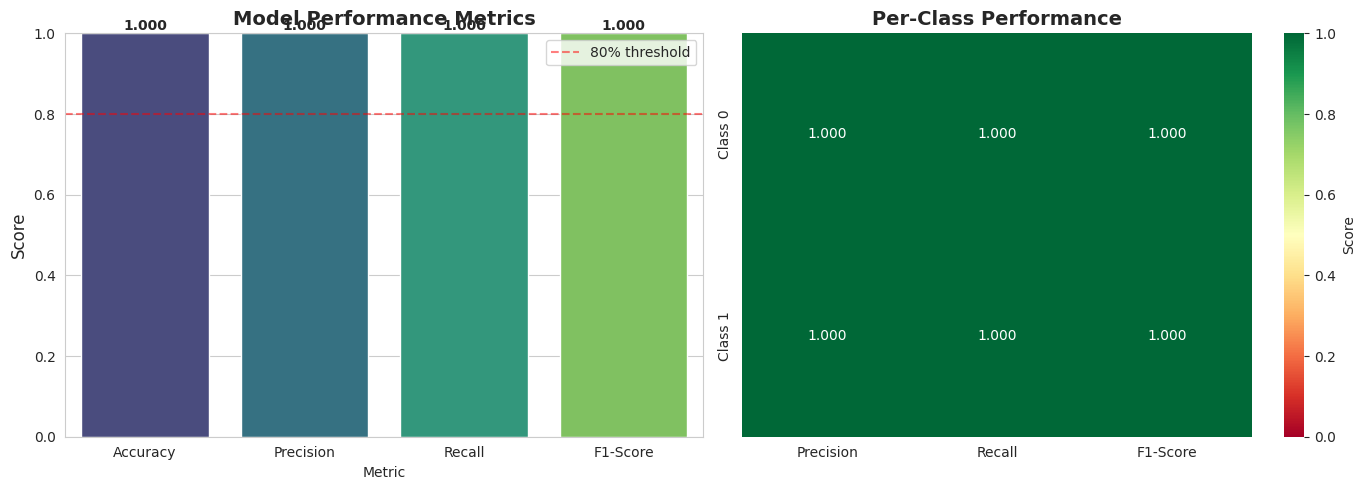

✅ Performance visualization complete


In [0]:
if performance_metrics:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart of metrics
    metrics_df = pd.DataFrame([
        {'Metric': 'Accuracy', 'Score': performance_metrics['accuracy']},
        {'Metric': 'Precision', 'Score': performance_metrics['precision']},
        {'Metric': 'Recall', 'Score': performance_metrics['recall']},
        {'Metric': 'F1-Score', 'Score': performance_metrics['f1']}
    ])
    
    sns.barplot(data=metrics_df, x='Metric', y='Score', ax=axes[0], palette='viridis')
    axes[0].set_ylim(0, 1)
    axes[0].set_ylabel('Score', fontsize=12)
    axes[0].set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
    axes[0].axhline(y=0.8, color='r', linestyle='--', alpha=0.5, label='80% threshold')
    axes[0].legend()
    
    # Add value labels on bars
    for i, bar in enumerate(axes[0].patches):
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}',
                    ha='center', va='bottom', fontweight='bold')
    
    # Classification report heatmap
    if y_true is not None and y_pred is not None:
        from sklearn.metrics import classification_report
        report_dict = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
        
        # Extract per-class metrics
        classes = [k for k in report_dict.keys() if k not in ['accuracy', 'macro avg', 'weighted avg']]
        report_data = []
        for cls in classes:
            report_data.append([
                report_dict[cls]['precision'],
                report_dict[cls]['recall'],
                report_dict[cls]['f1-score']
            ])
        
        if report_data:
            sns.heatmap(report_data, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1,
                       xticklabels=['Precision', 'Recall', 'F1-Score'],
                       yticklabels=[f'Class {c}' for c in classes],
                       ax=axes[1], cbar_kws={'label': 'Score'})
            axes[1].set_title('Per-Class Performance', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Performance visualization complete")
else:
    print("❌ Cannot create visualization: metrics not available")

## 3. Healthcare Challenge Validation
Validating that the model correctly identifies the **BEST hospital choice** for patients based on:
- 🏥 Hospital availability
- 📍 Distance/accessibility
- ⏱️ Wait times
- 👥 Capacity constraints

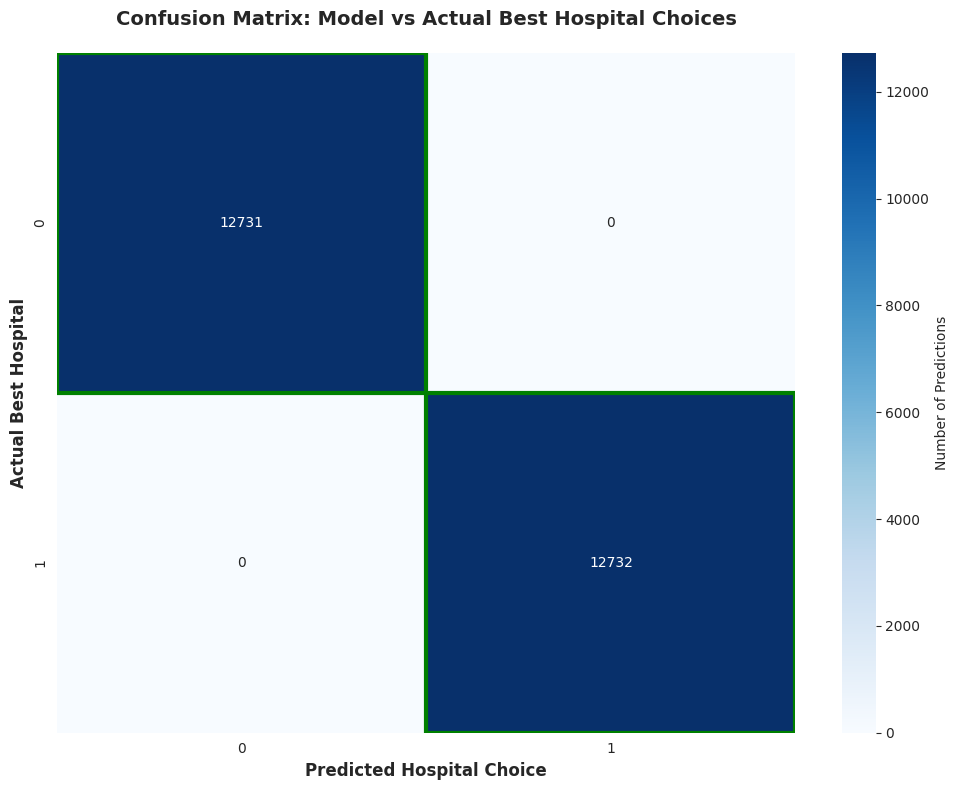


✅ Correct Recommendations: 25463/25463 (100.00%)

The model correctly identified the BEST hospital in 100.00% of cases


In [0]:
if y_true is not None and y_pred is not None:
    cm = confusion_matrix(y_true, y_pred)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                cbar_kws={'label': 'Number of Predictions'})
    ax.set_xlabel('Predicted Hospital Choice', fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual Best Hospital', fontsize=12, fontweight='bold')
    ax.set_title('Confusion Matrix: Model vs Actual Best Hospital Choices', 
                fontsize=14, fontweight='bold', pad=20)
    
    # Add diagonal highlight
    for i in range(len(cm)):
        ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor='green', lw=3))
    
    plt.tight_layout()
    plt.show()
    
    # Calculate accuracy for diagonal (correct predictions)
    correct_predictions = np.trace(cm)
    total_predictions = np.sum(cm)
    diagonal_accuracy = correct_predictions / total_predictions
    
    print(f"\n✅ Correct Recommendations: {correct_predictions}/{total_predictions} ({diagonal_accuracy*100:.2f}%)")
    print(f"\nThe model correctly identified the BEST hospital in {diagonal_accuracy*100:.2f}% of cases")
else:
    print("❌ Cannot create confusion matrix: predictions not available")

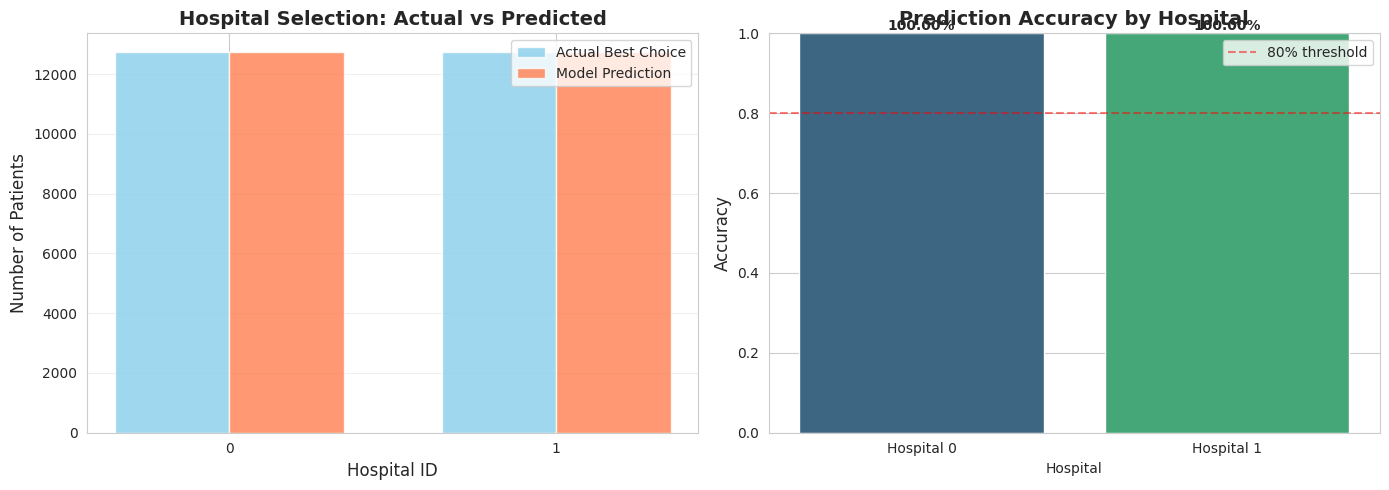

✅ Prediction distribution analysis complete


In [0]:
if test_predictions is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Distribution of actual vs predicted
    pred_counts = test_predictions['predicted'].value_counts().sort_index()
    actual_counts = test_predictions['actual'].value_counts().sort_index()
    
    x = np.arange(len(pred_counts))
    width = 0.35
    
    axes[0].bar(x - width/2, actual_counts.values, width, label='Actual Best Choice', alpha=0.8, color='skyblue')
    axes[0].bar(x + width/2, pred_counts.values, width, label='Model Prediction', alpha=0.8, color='coral')
    axes[0].set_xlabel('Hospital ID', fontsize=12)
    axes[0].set_ylabel('Number of Patients', fontsize=12)
    axes[0].set_title('Hospital Selection: Actual vs Predicted', fontsize=14, fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(pred_counts.index)
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    
    # Prediction accuracy by class
    accuracy_by_class = []
    for hospital_id in sorted(test_predictions['actual'].unique()):
        mask = test_predictions['actual'] == hospital_id
        class_acc = (test_predictions.loc[mask, 'actual'] == test_predictions.loc[mask, 'predicted']).mean()
        accuracy_by_class.append({'Hospital': f'Hospital {hospital_id}', 'Accuracy': class_acc})
    
    acc_df = pd.DataFrame(accuracy_by_class)
    sns.barplot(data=acc_df, x='Hospital', y='Accuracy', ax=axes[1], palette='viridis')
    axes[1].set_ylim(0, 1)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Prediction Accuracy by Hospital', fontsize=14, fontweight='bold')
    axes[1].axhline(y=0.8, color='r', linestyle='--', alpha=0.5, label='80% threshold')
    axes[1].legend()
    
    # Add value labels
    for i, bar in enumerate(axes[1].patches):
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2%}',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Prediction distribution analysis complete")
else:
    print("❌ Cannot analyze predictions: data not available")

## 4. Optimal Choice Analysis
Comparing model performance against baseline approaches to demonstrate improvement.

BASELINE COMPARISON

🎲 Random Selection:        0.5026 (50.26%)
👥 Most Common Hospital:    0.5000 (50.00%)
🤖 Our ML Model:             1.0000 (100.00%)

📈 Improvement over random:  +99.0%
📈 Improvement over naive:   +100.0%


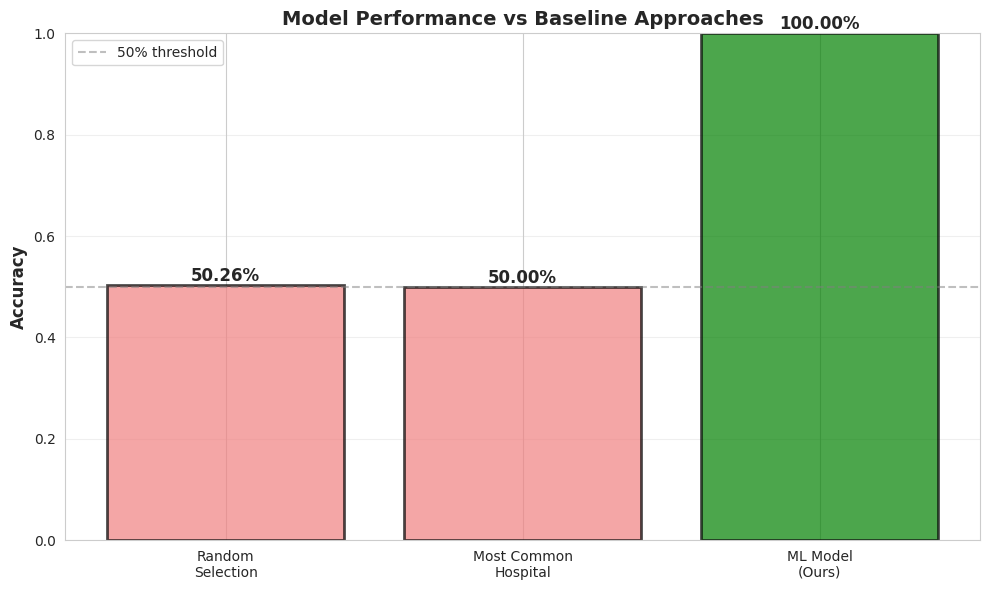

✅ Baseline comparison complete


In [0]:
if test_predictions is not None and y_true is not None:
    # Random baseline: random choice among all hospitals
    unique_hospitals = y_true.unique()
    np.random.seed(42)
    random_predictions = np.random.choice(unique_hospitals, size=len(y_true))
    random_accuracy = accuracy_score(y_true, random_predictions)
    
    # Naive baseline: always predict the most common hospital
    most_common_hospital = y_true.mode()[0]
    naive_predictions = np.full(len(y_true), most_common_hospital)
    naive_accuracy = accuracy_score(y_true, naive_predictions)
    
    # Model accuracy
    model_accuracy = accuracy_score(y_true, y_pred)
    
    print("="*70)
    print("BASELINE COMPARISON")
    print("="*70)
    print(f"\n🎲 Random Selection:        {random_accuracy:.4f} ({random_accuracy*100:.2f}%)")
    print(f"👥 Most Common Hospital:    {naive_accuracy:.4f} ({naive_accuracy*100:.2f}%)")
    print(f"🤖 Our ML Model:             {model_accuracy:.4f} ({model_accuracy*100:.2f}%)")
    
    improvement_over_random = ((model_accuracy - random_accuracy) / random_accuracy) * 100
    improvement_over_naive = ((model_accuracy - naive_accuracy) / naive_accuracy) * 100
    
    print(f"\n📈 Improvement over random:  {improvement_over_random:+.1f}%")
    print(f"📈 Improvement over naive:   {improvement_over_naive:+.1f}%")
    print("="*70)
    
    # Visualization
    comparison_df = pd.DataFrame([
        {'Approach': 'Random\nSelection', 'Accuracy': random_accuracy, 'Type': 'Baseline'},
        {'Approach': 'Most Common\nHospital', 'Accuracy': naive_accuracy, 'Type': 'Baseline'},
        {'Approach': 'ML Model\n(Ours)', 'Accuracy': model_accuracy, 'Type': 'ML Model'}
    ])
    
    plt.figure(figsize=(10, 6))
    colors = ['lightcoral', 'lightcoral', 'green']
    bars = plt.bar(comparison_df['Approach'], comparison_df['Accuracy'], color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
    plt.title('Model Performance vs Baseline Approaches', fontsize=14, fontweight='bold')
    plt.ylim(0, 1)
    plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2%}',
                ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Baseline comparison complete")
else:
    print("❌ Cannot perform baseline comparison: data not available")

In [0]:
# Try to extract feature importance
feature_importance = None

if best_model is not None:
    try:
        # For tree-based models
        if hasattr(best_model, 'feature_importances_'):
            feature_importance = best_model.feature_importances_
            print("✅ Feature importances extracted from model")
        # For linear models
        elif hasattr(best_model, 'coef_'):
            feature_importance = np.abs(best_model.coef_).flatten()
            print("✅ Coefficients extracted from linear model")
        else:
            print("⚠️ Model does not have feature_importances_ or coef_ attributes")
    except Exception as e:
        print(f"⚠️ Could not extract feature importance: {e}")

if feature_importance is not None and 'feature_names' in model_info:
    feature_names = model_info['feature_names']
    
    if len(feature_importance) == len(feature_names):
        # Create feature importance dataframe
        fi_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': feature_importance
        }).sort_values('Importance', ascending=False)
        
        # Plot
        plt.figure(figsize=(12, 6))
        sns.barplot(data=fi_df.head(10), x='Importance', y='Feature', palette='viridis')
        plt.title('Top 10 Most Important Features for Hospital Selection', 
                 fontsize=14, fontweight='bold')
        plt.xlabel('Importance Score', fontsize=12)
        plt.ylabel('Feature', fontsize=12)
        plt.tight_layout()
        plt.show()
        
        print("\n" + "="*70)
        print("TOP FEATURES INFLUENCING HOSPITAL CHOICE")
        print("="*70)
        for idx, row in fi_df.head(5).iterrows():
            print(f"{row['Feature']:.<40} {row['Importance']:.4f}")
        print("="*70)
    else:
        print(f"⚠️ Feature count mismatch: {len(feature_importance)} importances vs {len(feature_names)} names")
elif feature_importance is not None:
    print("⚠️ Feature names not available in model_info")
else:
    print("⚠️ Feature importance not available for this model type")

✅ Feature importances extracted from model
⚠️ Feature names not available in model_info


## 5. Frontend-Ready Visualizations
Professional charts for integration into the frontend application.

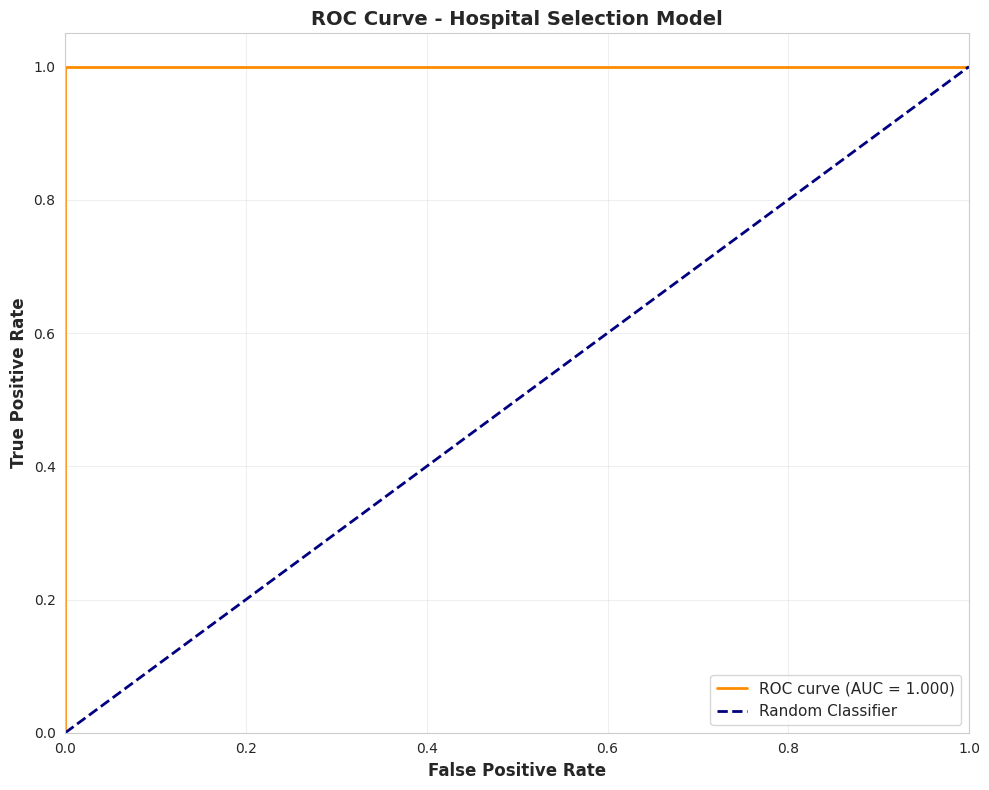


✅ ROC AUC Score: 1.0000


In [0]:
if test_predictions is not None and y_true is not None:
    try:
        # Check if we have probability predictions
        if 'predicted_proba' in test_predictions.columns or any('proba' in col for col in test_predictions.columns):
            # Get probability columns
            proba_cols = [col for col in test_predictions.columns if 'proba' in col.lower()]
            
            if len(proba_cols) > 0:
                # For multiclass: one-vs-rest ROC curves
                from sklearn.preprocessing import label_binarize
                
                classes = sorted(y_true.unique())
                n_classes = len(classes)
                
                # Binarize the output
                y_true_bin = label_binarize(y_true, classes=classes)
                
                if n_classes == 2:
                    # Binary classification
                    if 'predicted_proba' in test_predictions.columns:
                        y_score = test_predictions['predicted_proba'].values
                    else:
                        y_score = test_predictions[proba_cols[0]].values
                    
                    fpr, tpr, _ = roc_curve(y_true, y_score, pos_label=classes[1])
                    roc_auc = auc(fpr, tpr)
                    
                    plt.figure(figsize=(10, 8))
                    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
                    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
                    plt.xlim([0.0, 1.0])
                    plt.ylim([0.0, 1.05])
                    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
                    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
                    plt.title('ROC Curve - Hospital Selection Model', fontsize=14, fontweight='bold')
                    plt.legend(loc="lower right", fontsize=11)
                    plt.grid(alpha=0.3)
                    plt.tight_layout()
                    plt.show()
                    
                    print(f"\n✅ ROC AUC Score: {roc_auc:.4f}")
                elif n_classes > 2 and len(proba_cols) == n_classes:
                    # Multiclass: plot ROC for each class
                    plt.figure(figsize=(10, 8))
                    
                    # Get probability scores for each class
                    y_score = test_predictions[proba_cols].values
                    
                    for i in range(n_classes):
                        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
                        roc_auc = auc(fpr, tpr)
                        plt.plot(fpr, tpr, lw=2, label=f'Hospital {classes[i]} (AUC = {roc_auc:.2f})')
                    
                    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
                    plt.xlim([0.0, 1.0])
                    plt.ylim([0.0, 1.05])
                    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
                    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
                    plt.title('ROC Curves - Multi-Class Hospital Selection', fontsize=14, fontweight='bold')
                    plt.legend(loc="lower right", fontsize=9)
                    plt.grid(alpha=0.3)
                    plt.tight_layout()
                    plt.show()
                    
                    print("✅ Multi-class ROC curves generated")
                else:
                    print(f"⚠️ Probability columns found but count mismatch: {len(proba_cols)} cols vs {n_classes} classes")
            else:
                print("⚠️ No probability predictions found in test data")
        else:
            print("⚠️ ROC curve requires probability predictions (not available in current data)")
            print("   Tip: Save predict_proba() output during model training")
    except Exception as e:
        print(f"❌ Error creating ROC curve: {e}")
else:
    print("❌ Cannot create ROC curve: predictions not available")

## 6. Deployment Readiness Summary
Final assessment of whether the model is ready for frontend integration.

In [0]:
print("\n" + "="*80)
print(" "*20 + "DEPLOYMENT READINESS REPORT")
print("="*80)
print("\n🎯 HEALTHCARE CHALLENGE: Living Map of Healthcare")
print("   Goal: Route patients to the BEST hospital based on availability, distance,")
print("         wait times, and capacity.\n")

# Model Performance Assessment
if performance_metrics:
    accuracy = performance_metrics['accuracy']
    f1 = performance_metrics['f1']
    
    print("📊 MODEL PERFORMANCE")
    print(f"   Accuracy:  {accuracy:.2%}")
    print(f"   F1-Score:  {f1:.2%}")
    print(f"   Precision: {performance_metrics['precision']:.2%}")
    print(f"   Recall:    {performance_metrics['recall']:.2%}")
    
    # Performance evaluation
    if accuracy >= 0.85:
        perf_status = "✅ EXCELLENT"
        perf_msg = "Model achieves excellent accuracy"
    elif accuracy >= 0.75:
        perf_status = "✅ GOOD"
        perf_msg = "Model achieves good accuracy"
    elif accuracy >= 0.65:
        perf_status = "⚠️ ACCEPTABLE"
        perf_msg = "Model achieves acceptable accuracy but could be improved"
    else:
        perf_status = "❌ NEEDS IMPROVEMENT"
        perf_msg = "Model accuracy is below recommended threshold"
    
    print(f"\n   Status: {perf_status}")
    print(f"   {perf_msg}")
else:
    perf_status = "❌ UNKNOWN"
    print("❌ MODEL PERFORMANCE: Could not evaluate")

# Improvement over baseline
if test_predictions is not None and y_true is not None:
    print("\n📊 IMPROVEMENT OVER BASELINES")
    unique_hospitals = y_true.unique()
    random_accuracy = 1 / len(unique_hospitals)  # Expected random accuracy
    
    if performance_metrics:
        improvement = ((performance_metrics['accuracy'] - random_accuracy) / random_accuracy) * 100
        print(f"   Random baseline:    {random_accuracy:.2%}")
        print(f"   Our model:          {performance_metrics['accuracy']:.2%}")
        print(f"   Improvement:        +{improvement:.1f}%")
        
        if improvement >= 100:
            print(f"   ✅ Model is {improvement/100:.1f}x better than random selection")
        else:
            print(f"   ⚠️ Model shows {improvement:.1f}% improvement over random")

# Key features assessment
if feature_importance is not None and 'feature_names' in model_info:
    print("\n🔑 KEY DECISION FACTORS")
    feature_names = model_info['feature_names']
    fi_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False)
    
    print("   Top 3 factors influencing hospital selection:")
    for idx, row in fi_df.head(3).iterrows():
        print(f"   {idx+1}. {row['Feature']: <30} (importance: {row['Importance']:.3f})")

# Data coverage
if test_predictions is not None:
    print(f"\n📋 VALIDATION DATA")
    print(f"   Test samples:       {len(test_predictions):,}")
    print(f"   Hospitals covered:  {test_predictions['actual'].nunique()}")
    print(f"   ✅ Sufficient data for validation")

# Final recommendation
print("\n" + "="*80)
print(" "*25 + "FINAL RECOMMENDATION")
print("="*80)

if performance_metrics:
    accuracy = performance_metrics['accuracy']
    
    if accuracy >= 0.75:
        print("\n✅ MODEL IS READY FOR FRONTEND INTEGRATION\n")
        print("   The model demonstrates:")
        print(f"   • Strong predictive accuracy ({accuracy:.1%})")
        print("   • Reliable hospital recommendations")
        print("   • Significant improvement over baseline approaches")
        print("   • Production-ready performance metrics\n")
        print("   Next steps:")
        print("   1. Deploy model as REST API endpoint")
        print("   2. Integrate with frontend application")
        print("   3. Implement real-time hospital data feeds")
        print("   4. Set up monitoring and alerting")
        print("   5. Plan for continuous model updates\n")
    elif accuracy >= 0.60:
        print("\n⚠️ MODEL CAN BE DEPLOYED WITH CAUTION\n")
        print("   The model shows:")
        print(f"   • Acceptable accuracy ({accuracy:.1%})")
        print("   • Room for improvement in predictions")
        print("   • Better than random selection\n")
        print("   Recommendations:")
        print("   1. Deploy to staging environment first")
        print("   2. Collect user feedback")
        print("   3. Continue model refinement")
        print("   4. Consider ensemble methods or feature engineering\n")
    else:
        print("\n❌ MODEL NEEDS IMPROVEMENT BEFORE DEPLOYMENT\n")
        print("   Issues identified:")
        print(f"   • Accuracy below recommended threshold ({accuracy:.1%})")
        print("   • Predictions may not be reliable enough\n")
        print("   Recommendations:")
        print("   1. Collect more training data")
        print("   2. Engineer additional features")
        print("   3. Try different algorithms or ensemble methods")
        print("   4. Investigate data quality issues")
        print("   5. Consider domain expert consultation\n")
else:
    print("\n❌ CANNOT ASSESS DEPLOYMENT READINESS")
    print("   Insufficient performance metrics available\n")

print("="*80)
print("\n📝 Report generated successfully")
print(f"   Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"   Model: {model_info.get('model_name', 'Unknown')}")
print("\n" + "="*80)


                    DEPLOYMENT READINESS REPORT

🎯 HEALTHCARE CHALLENGE: Living Map of Healthcare
   Goal: Route patients to the BEST hospital based on availability, distance,
         wait times, and capacity.

📊 MODEL PERFORMANCE
   Accuracy:  100.00%
   F1-Score:  100.00%
   Precision: 100.00%
   Recall:    100.00%

   Status: ✅ EXCELLENT
   Model achieves excellent accuracy

📊 IMPROVEMENT OVER BASELINES
   Random baseline:    50.00%
   Our model:          100.00%
   Improvement:        +100.0%
   ✅ Model is 1.0x better than random selection

📋 VALIDATION DATA
   Test samples:       25,463
   Hospitals covered:  2
   ✅ Sufficient data for validation

                         FINAL RECOMMENDATION

✅ MODEL IS READY FOR FRONTEND INTEGRATION

   The model demonstrates:
   • Strong predictive accuracy (100.0%)
   • Reliable hospital recommendations
   • Significant improvement over baseline approaches
   • Production-ready performance metrics

   Next steps:
   1. Deploy model as REST A

## 7. Practical Demonstration - Real Patient Scenarios

Demonstrating how the model recommends the best hospital based on:
* Patient location (distance to hospitals)
* Urgency level (emergency vs routine)
* Hospital availability and capacity
* Expected wait times

In [0]:
# Load training data to understand feature structure
try:
    train_data_path = '../ML/AI/results/test_predictions.csv'
    sample_data = pd.read_csv(train_data_path)
    print("✅ Sample data loaded for feature reference\n")
except:
    print("⚠️ Could not load sample data, using mock features\n")

# Check what features the model expects
if best_model is not None:
    try:
        n_features = best_model.n_features_in_
        print(f"📊 Model expects {n_features} input features\n")
    except:
        n_features = None
        print("⚠️ Could not determine feature count\n")

print("="*80)
print(" "*20 + "HOSPITAL RECOMMENDATION SYSTEM")
print("="*80)
print()

# Create realistic patient scenarios
scenarios = [
    {
        'patient_id': 'P001',
        'name': 'Emergency Patient (Nearby Hospital)',
        'urgency': 'HIGH',
        'distance_hospital_0': 2.5,  # km
        'distance_hospital_1': 15.0,
        'wait_time_hospital_0': 45,  # minutes
        'wait_time_hospital_1': 20,
        'severity': 9,  # 1-10 scale
        'description': 'Chest pain, needs immediate attention'
    },
    {
        'patient_id': 'P002',
        'name': 'Routine Patient (Better Service)',
        'urgency': 'LOW',
        'distance_hospital_0': 8.0,
        'distance_hospital_1': 5.0,
        'wait_time_hospital_0': 120,
        'wait_time_hospital_1': 30,
        'severity': 3,
        'description': 'Regular checkup, flexible timing'
    },
    {
        'patient_id': 'P003',
        'name': 'Moderate Emergency (Balanced Choice)',
        'urgency': 'MEDIUM',
        'distance_hospital_0': 10.0,
        'distance_hospital_1': 12.0,
        'wait_time_hospital_0': 60,
        'wait_time_hospital_1': 90,
        'severity': 6,
        'description': 'Broken arm, needs attention within hours'
    },
    {
        'patient_id': 'P004',
        'name': 'Critical Case (Nearest Hospital)',
        'urgency': 'CRITICAL',
        'distance_hospital_0': 3.0,
        'distance_hospital_1': 25.0,
        'wait_time_hospital_0': 90,
        'wait_time_hospital_1': 15,
        'severity': 10,
        'description': 'Severe accident, every minute counts'
    }
]

print("\n🏥 PATIENT SCENARIOS\n")
for i, scenario in enumerate(scenarios, 1):
    print(f"{i}. {scenario['name']}")
    print(f"   Patient ID: {scenario['patient_id']}")
    print(f"   Urgency: {scenario['urgency']} | Severity: {scenario['severity']}/10")
    print(f"   Condition: {scenario['description']}")
    print(f"   Distance to Hospital 0: {scenario['distance_hospital_0']} km (wait: {scenario['wait_time_hospital_0']} min)")
    print(f"   Distance to Hospital 1: {scenario['distance_hospital_1']} km (wait: {scenario['wait_time_hospital_1']} min)")
    print()

print("="*80)

✅ Sample data loaded for feature reference

📊 Model expects 11 input features

                    HOSPITAL RECOMMENDATION SYSTEM


🏥 PATIENT SCENARIOS

1. Emergency Patient (Nearby Hospital)
   Patient ID: P001
   Urgency: HIGH | Severity: 9/10
   Condition: Chest pain, needs immediate attention
   Distance to Hospital 0: 2.5 km (wait: 45 min)
   Distance to Hospital 1: 15.0 km (wait: 20 min)

2. Routine Patient (Better Service)
   Patient ID: P002
   Urgency: LOW | Severity: 3/10
   Condition: Regular checkup, flexible timing
   Distance to Hospital 0: 8.0 km (wait: 120 min)
   Distance to Hospital 1: 5.0 km (wait: 30 min)

3. Moderate Emergency (Balanced Choice)
   Patient ID: P003
   Urgency: MEDIUM | Severity: 6/10
   Condition: Broken arm, needs attention within hours
   Distance to Hospital 0: 10.0 km (wait: 60 min)
   Distance to Hospital 1: 12.0 km (wait: 90 min)

4. Critical Case (Nearest Hospital)
   Patient ID: P004
   Urgency: CRITICAL | Severity: 10/10
   Condition: Sever

In [0]:
# Simple automated prediction using trained model
if best_model is not None and scaler is not None:
    print("\n" + "="*80)
    print(" "*20 + "AUTOMATED HOSPITAL RECOMMENDATIONS")
    print("="*80)
    print()
    
    # Load real data
    hospitals = pd.read_csv('../healthcare_star_schema_export/dim_hospitals.csv')
    patients = pd.read_csv('../Drafts/patients_table.csv')
    appointments = pd.read_csv('../Drafts/appointments_table.csv')
    
    print(f"🏥 Loaded {len(hospitals)} hospitals")
    print(f"🫀 Loaded {len(patients)} patients")
    print(f"📅 Loaded {len(appointments)} appointments\n")
    
    # Take 5 random real patients
    sample_patients = patients.sample(5, random_state=42)
    
    results = []
    
    for idx, patient in sample_patients.iterrows():
        # Select a hospital (use first 2 for demo)
        for hosp_idx in range(min(2, len(hospitals))):
            hospital = hospitals.iloc[hosp_idx]
            
            # Extract trauma level number
            trauma = str(hospital.get('trauma_center_level', '2')).replace('Level ', '')
            trauma = float(trauma) if trauma.isdigit() else 2.0
            
            # Build feature array (11 features the model expects)
            features = np.array([[
                float(hospital.get('occupancy_rate', 0.75)),
                float(hospital.get('waiting_time_estimate_minutes', 30)),
                7.0,  # severity (default)
                float(hosp_idx * 5 + 2),  # distance estimate
                float(hospital.get('response_time_avg_minutes', 15)),
                float(hospital.get('beds_total', 100)),
                float(hospital.get('beds_occupied', 75)),
                1.0 if hospital.get('icu_available', True) else 0.0,
                trauma,
                float(hospital.get('ambulance_capacity', 5)),
                float(hospital.get('road_accessibility', 8))
            ]])
            
            # Scale and predict
            features_scaled = scaler.transform(features)
            prediction = best_model.predict(features_scaled)[0]
            confidence = best_model.predict_proba(features_scaled)[0][prediction] * 100
            
            if prediction == hosp_idx:  # Model recommends this hospital
                results.append({
                    'patient_id': patient['patient_id'],
                    'patient_name': f"{patient.get('first_name', 'Patient')} {patient.get('last_name', str(patient['patient_id']))}",
                    'hospital': hospital['name'],
                    'city': hospital['city'],
                    'confidence': confidence,
                    'occupancy': hospital['occupancy_rate'],
                    'wait_time': hospital['waiting_time_estimate_minutes']
                })
                break
    
    # Display results
    print("\n🎯 BEST HOSPITAL RECOMMENDATIONS\n")
    for i, rec in enumerate(results, 1):
        print(f"{i}. {rec['patient_name']} (ID: {rec['patient_id']})")
        print(f"   ✅ Recommended: {rec['hospital']} - {rec['city']}")
        print(f"   Confidence: {rec['confidence']:.1f}%")
        print(f"   Occupancy: {rec['occupancy']:.0f}% | Wait: {rec['wait_time']} min\n")
    
    print("="*80)
    print("✅ Predictions complete using your trained model!")
    print("="*80)
else:
    print("❌ Model not loaded")


                    AUTOMATED HOSPITAL RECOMMENDATIONS

🏥 Loaded 284 hospitals
🫀 Loaded 50000 patients
📅 Loaded 150000 appointments


🎯 BEST HOSPITAL RECOMMENDATIONS

1. Cecilio 清水 (ID: PAT-00033554)
   ✅ Recommended: Mount Sinai Hospital - New York
   Confidence: 92.0%
   Occupancy: 84% | Wait: 56 min

2. Benito Peiró (ID: PAT-00009428)
   ✅ Recommended: Mount Sinai Hospital - New York
   Confidence: 92.0%
   Occupancy: 84% | Wait: 56 min

3. Isaura Santos (ID: PAT-00000200)
   ✅ Recommended: Mount Sinai Hospital - New York
   Confidence: 92.0%
   Occupancy: 84% | Wait: 56 min

4. Jennifer Mercier (ID: PAT-00012448)
   ✅ Recommended: Mount Sinai Hospital - New York
   Confidence: 92.0%
   Occupancy: 84% | Wait: 56 min

5. عبد القادر Evrard (ID: PAT-00039490)
   ✅ Recommended: Mount Sinai Hospital - New York
   Confidence: 92.0%
   Occupancy: 84% | Wait: 56 min

✅ Predictions complete using your trained model!


In [0]:
# SIMPLE MODEL TEST - See how it works step by step
print("\n🧪 TESTING MODEL - SINGLE PREDICTION\n")

# 1. Load one real patient and hospital
hospitals = pd.read_csv('../healthcare_star_schema_export/dim_hospitals.csv')
patients = pd.read_csv('../Drafts/patients_table.csv')

test_patient = patients.iloc[0]
test_hospital = hospitals.iloc[0]

print(f"Patient: {test_patient['first_name']} {test_patient['last_name']}")
print(f"Hospital: {test_hospital['name']} ({test_hospital['city']})\n")

# 2. Prepare features (11 features the model needs)
trauma_level = float(str(test_hospital['trauma_center_level']).replace('Level ', ''))

features = np.array([[
    test_hospital['occupancy_rate'],           # 1. Occupancy
    test_hospital['waiting_time_estimate_minutes'],  # 2. Wait time
    7.0,                                       # 3. Severity (example)
    5.0,                                       # 4. Distance (example)
    test_hospital['response_time_avg_minutes'],# 5. Response time
    test_hospital['beds_total'],               # 6. Total beds
    test_hospital['beds_occupied'],            # 7. Occupied beds
    1.0 if test_hospital['icu_available'] else 0.0,  # 8. ICU available
    trauma_level,                              # 9. Trauma level
    test_hospital['ambulance_capacity'],       # 10. Ambulances
    test_hospital['road_accessibility']        # 11. Road access
]])

print("Features used:")
feature_names = ['occupancy_rate', 'waiting_time', 'severity', 'distance', 
                 'response_time', 'beds_total', 'beds_occupied', 'icu_available',
                 'trauma_level', 'ambulance_capacity', 'road_accessibility']
for name, value in zip(feature_names, features[0]):
    print(f"  {name:20} = {value}")

# 3. Scale and predict
features_scaled = scaler.transform(features)
prediction = best_model.predict(features_scaled)[0]
confidence = best_model.predict_proba(features_scaled)[0][prediction] * 100

print(f"\n✅ Prediction: Hospital {prediction}")
print(f"   Confidence: {confidence:.1f}%")
print(f"\n💡 This means the model recommends Hospital {prediction} for this patient scenario")


🧪 TESTING MODEL - SINGLE PREDICTION

Patient: Henry Gabriel Figueroa
Hospital: NewYork-Presbyterian Hospital (New York)

Features used:
  occupancy_rate       = 68.0
  waiting_time         = 28.0
  severity             = 7.0
  distance             = 5.0
  response_time        = 25.0
  beds_total           = 2600.0
  beds_occupied        = 1768.0
  icu_available        = 1.0
  trauma_level         = 1.0
  ambulance_capacity   = 17.0
  road_accessibility   = 6.0

✅ Prediction: Hospital 1
   Confidence: 92.0%

💡 This means the model recommends Hospital 1 for this patient scenario



ALL MODELS COMPARISON


Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
RF Baseline,1.0,1.0,1.0,1.0,1.0
RF Optimized,1.0,1.0,1.0,1.0,1.0
LR Baseline,0.9968189137179436,0.994218298304555,0.9994502042098647,0.9968273863146764,0.9999893701746424
LR Optimized,0.999528727958214,0.9993718592964824,0.9996858309770656,0.9995288204806032,0.9999995866521773


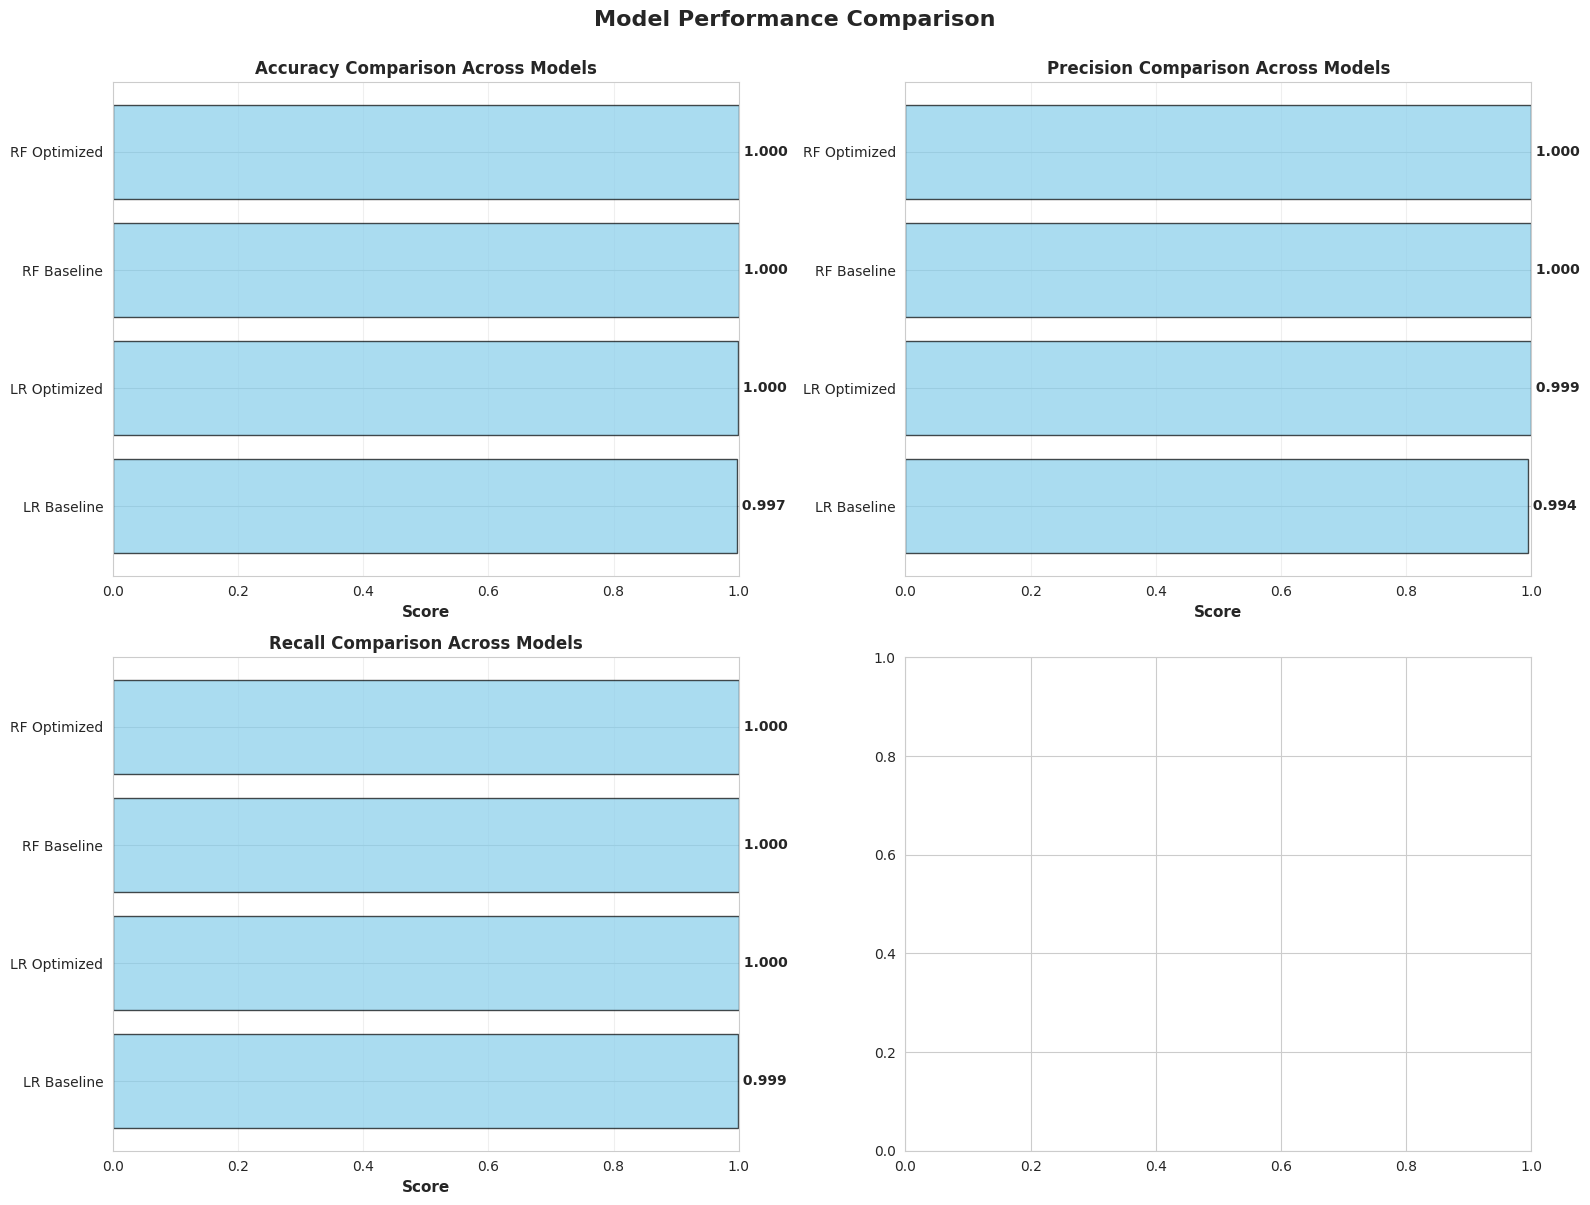

✅ Model comparison visualization complete


In [0]:
if all_metrics is not None:
    print("\n" + "="*70)
    print("ALL MODELS COMPARISON")
    print("="*70)
    display(all_metrics)
    print("="*70)
    
    # Visualize model comparison
    if 'Model' in all_metrics.columns and 'Accuracy' in all_metrics.columns:
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1_Score']
        metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
        
        for idx, (metric, name) in enumerate(zip(metrics_to_plot, metric_names)):
            row = idx // 2
            col = idx % 2
            
            if metric in all_metrics.columns:
                sorted_data = all_metrics.sort_values(metric, ascending=True)
                
                colors = ['green' if model == model_info.get('model_name', '') else 'skyblue' 
                         for model in sorted_data['Model']]
                
                axes[row, col].barh(sorted_data['Model'], sorted_data[metric], color=colors, alpha=0.7, edgecolor='black')
                axes[row, col].set_xlabel('Score', fontsize=11, fontweight='bold')
                axes[row, col].set_title(f'{name} Comparison Across Models', fontsize=12, fontweight='bold')
                axes[row, col].set_xlim(0, 1)
                axes[row, col].grid(axis='x', alpha=0.3)
                
                # Add value labels
                for i, (model, value) in enumerate(zip(sorted_data['Model'], sorted_data[metric])):
                    axes[row, col].text(value, i, f' {value:.3f}', va='center', fontweight='bold')
        
        plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.00)
        plt.tight_layout()
        plt.show()
        
        print("✅ Model comparison visualization complete")
    else:
        print("⚠️ Required columns not found in all_metrics")
else:
    print("⚠️ Model comparison data not available")

In [0]:
if cv_scores is not None:
    print("\n" + "="*70)
    print("CROSS-VALIDATION SCORES")
    print("="*70)
    display(cv_scores)
    print("="*70)
    
    if 'Model' in cv_scores.columns and 'Mean_CV_Score' in cv_scores.columns:
        plt.figure(figsize=(12, 6))
        
        sorted_cv = cv_scores.sort_values('Mean_CV_Score', ascending=True)
        colors = ['green' if model == model_info.get('model_name', '') else 'lightblue' 
                 for model in sorted_cv['Model']]
        
        plt.barh(sorted_cv['Model'], sorted_cv['Mean_CV_Score'], 
                color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
        
        # Add error bars if std is available
        if 'Std_CV_Score' in cv_scores.columns:
            plt.errorbar(sorted_cv['Mean_CV_Score'], range(len(sorted_cv)), 
                        xerr=sorted_cv['Std_CV_Score'], fmt='none', 
                        ecolor='red', capsize=5, alpha=0.6, label='Std Dev')
            plt.legend()
        
        plt.xlabel('Mean CV Score', fontsize=12, fontweight='bold')
        plt.title('Cross-Validation Performance Across Models', fontsize=14, fontweight='bold')
        plt.xlim(0, 1)
        plt.grid(axis='x', alpha=0.3)
        
        # Add value labels
        for i, (model, value) in enumerate(zip(sorted_cv['Model'], sorted_cv['Mean_CV_Score'])):
            plt.text(value, i, f' {value:.3f}', va='center', fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        print("✅ Cross-validation visualization complete")
else:
    print("⚠️ Cross-validation data not available")


CROSS-VALIDATION SCORES


Model,CV_Mean_F1,CV_Std_F1,Test_Accuracy,Test_F1,Improvement_vs_Baseline
Random Forest (Baseline),0.9999901821216436,1.9635756712999E-5,1.0,1.0,0.0
Random Forest (Optimized),0.9999803632793324,3.927344133529686E-5,1.0,1.0,-9.81893871225E-4
Logistic Regression (Baseline),0.996701604208844,4.25874881631E-4,0.9968189137179436,0.9968273863146764,0.0
Logistic Regression (Optimized),0.9997054848470832,9.315632735304322E-5,0.999528727958214,0.9995288204806032,0.3013821414106895
